# 1. Mission et contexte

On me confie le catalogue produit d'un e-commerçant britannique ([Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii), UCI Machine Learning Repository, 1 067 371 lignes de transaction, décembre 2009 à décembre 2011) : les fiches produit sont connues pour être incohérentes, mais personne n'a chiffré l'ampleur du problème ni ce qu'il coûte. Avant de proposer des corrections, je qualifie les anomalies et je les priorise par impact business plutôt que par intuition. C'est un angle différent du projet `customer-analytics-retail` (centré client) : ici l'unité d'analyse est le produit et sa fiche catalogue.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/raw/online_retail_ii.parquet")
df.shape

(1067371, 8)

In [2]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.dtypes.to_frame("dtype")

,dtype
Invoice,str
StockCode,str
Description,string
Quantity,int64
InvoiceDate,datetime64[us]
Price,float64
Customer ID,float64
Country,str


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394029,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Indicateurs retenus

Pour répondre à la mission (qualifier les anomalies, chiffrer leur coût, prioriser les corrections), je retiens quatre angles avant d'écrire le moindre calcul :

- **Audit qualité du catalogue** (codes non-produits, libellés incohérents, descriptions manquantes) : sans ça, aucun chiffre de performance produit n'est fiable.
- **Impact business en chiffre d'affaires**, pas en nombre de lignes : un compte de lignes ne dit rien de ce qu'une anomalie coûte réellement.
- **Croisement des meilleures ventes avec le statut qualité** : pour prioriser là où l'effort de correction rapporte le plus, pas dans un ordre arbitraire.
- **Taux d'annulation par produit** : seul proxy de conversion disponible dans ce jeu de données transactionnel, faute de données de navigation.

Chaque indicateur n'est calculé qu'après avoir exclu les codes non-produits (audit qualité, section suivante), pour ne pas polluer les résultats avec des lignes qui ne représentent pas de vrais articles.

# 3. Audit qualité du catalogue

Quatre constats, chacun quantifié en nombre de lignes/codes concernés.

In [5]:
# Q1 : codes non-produits mélangés au catalogue.
# Liste construite en inspectant les libellés de chaque code non conforme au format standard
# (5 chiffres), pas en devinant à partir du format seul : DCGS*, gift_0001_*, PADS, SP1002
# se sont avérés être de vrais produits une fois les libellés vérifiés, ils sont donc gardés.
NON_PRODUCT_CODES = ["ADJUST", "ADJUST2", "AMAZONFEE", "B", "BANK CHARGES", "C2", "C3",
                      "CRUK", "D", "DOT", "GIFT", "M", "m", "POST", "S", "TEST001", "TEST002"]

n_non_product_rows = df["StockCode"].isin(NON_PRODUCT_CODES).sum()
display(Markdown(
    f"**Q1** : {len(NON_PRODUCT_CODES)} codes confirmés non-produits (ajustements, frais, port, dons, tests), "
    f"soit {n_non_product_rows} lignes ({n_non_product_rows/len(df):.1%}) à exclure de tout calcul de performance produit."
))

**Q1** : 17 codes confirmés non-produits (ajustements, frais, port, dons, tests), soit 5813 lignes (0.5%) à exclure de tout calcul de performance produit.

In [6]:
prod = df[~df["StockCode"].isin(NON_PRODUCT_CODES)].copy()
prod["is_cancel"] = prod["Invoice"].str.startswith("C")
prod["revenue"] = prod["Quantity"] * prod["Price"]
prod.shape

(1061558, 10)

In [7]:
# Q2 : incohérence de libellé (plusieurs descriptions pour un même code)
desc_per_code = prod.dropna(subset=["Description"]).groupby("StockCode")["Description"].nunique()
multi_desc_codes = set(desc_per_code[desc_per_code > 1].index)

# Q3 : codes jamais décrits (aucune ligne avec une description valide, pas juste "quelques lignes manquantes")
has_valid_desc = set(prod.dropna(subset=["Description"])["StockCode"].unique())
never_described = set(prod["StockCode"].unique()) - has_valid_desc

# Q4 : lignes avec description manquante mais récupérable via une autre ligne du même code
codes_with_missing_row = set(prod.loc[prod["Description"].isna(), "StockCode"].unique())
recoverable_codes = codes_with_missing_row & has_valid_desc

quality_report = pd.DataFrame({
    "règle": ["Q2 libellé incohérent", "Q3 jamais décrit (orphelin)", "Q4 partiellement manquant (récupérable)"],
    "codes concernés": [len(multi_desc_codes), len(never_described), len(recoverable_codes)],
})
quality_report

,règle,codes concernés
0,Q2 libellé incohérent,1230
1,Q3 jamais décrit (orphelin),353
2,Q4 partiellement manquant (récupérable),2092


**Observations** La distinction Q3/Q4 est volontaire : un code "jamais décrit" est un vrai trou de catalogue (aucune ligne n'a de libellé exploitable), un code "partiellement manquant" a juste des lignes incomplètes récupérables par une jointure sur les lignes valides du même code. Confondre les deux surestimerait le problème réel.

# 4. Analyse univariée et bivariée

Avant de calculer les indicateurs ciblés, je regarde la forme des variables transactionnelles clés (`Price`, `Quantity`, `revenue`) et leurs relations générales, sur le catalogue déjà nettoyé des codes non-produits (`prod`).

**Univarié**

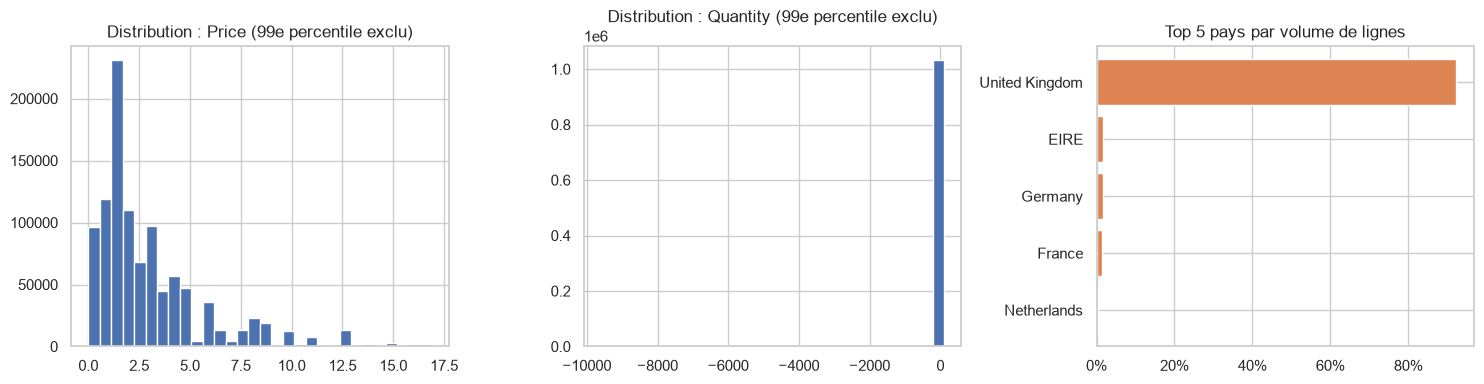

In [8]:
sold = prod.loc[~prod["is_cancel"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sold.loc[sold["Price"] < sold["Price"].quantile(0.99), "Price"], bins=30, color="#4C72B0")
axes[0].set_title("Distribution : Price (99e percentile exclu)")

axes[1].hist(sold.loc[sold["Quantity"] < sold["Quantity"].quantile(0.99), "Quantity"], bins=30, color="#4C72B0")
axes[1].set_title("Distribution : Quantity (99e percentile exclu)")

top_countries = sold["Country"].value_counts(normalize=True).head(5)
axes[2].barh(top_countries.index[::-1], top_countries.values[::-1], color="#DD8452")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[2].set_title("Top 5 pays par volume de lignes")

plt.tight_layout()
plt.savefig("../reports/univarie_distributions.png", dpi=150)
plt.show()

In [9]:
# découverte faite en observant la queue négative de Quantity : des lignes à quantité négative
# qui ne sont PAS des annulations (pas de préfixe "C" sur l'Invoice)
neg_qty_not_cancel = prod[(prod["Quantity"] < 0) & (~prod["is_cancel"])]

display(Markdown(
    f"**Observations** `Price` et `Quantity` sont tous deux très asymétriques à droite, ce qui confirmera "
    f"le choix de la médiane pour toute comparaison de valeur centrale sur ces variables. Le Royaume-Uni "
    f"représente {top_countries.iloc[0]:.1%} des lignes, le catalogue est quasi mono-pays.\n\n"
    f"Point inattendu : {len(neg_qty_not_cancel)} lignes ont une quantité négative sans être des annulations "
    f"(pas de préfixe `C` sur la facture), toutes à prix nul, avec des libellés comme *lost*, *damages*, "
    f"*short* ou *mixed*. Ce sont des écritures d'ajustement de stock, pas des ventes ni des annulations "
    f"client. Comme leur prix est nul, elles n'affectent pas les CA calculés plus haut, mais ce sont des "
    f"lignes à garder à l'œil si le champ `Quantity` est réutilisé ailleurs sans filtrer sur le prix."
))

**Observations** `Price` et `Quantity` sont tous deux très asymétriques à droite, ce qui confirmera le choix de la médiane pour toute comparaison de valeur centrale sur ces variables. Le Royaume-Uni représente 92.2% des lignes, le catalogue est quasi mono-pays.

Point inattendu : 3455 lignes ont une quantité négative sans être des annulations (pas de préfixe `C` sur la facture), toutes à prix nul, avec des libellés comme *lost*, *damages*, *short* ou *mixed*. Ce sont des écritures d'ajustement de stock, pas des ventes ni des annulations client. Comme leur prix est nul, elles n'affectent pas les CA calculés plus haut, mais ce sont des lignes à garder à l'œil si le champ `Quantity` est réutilisé ailleurs sans filtrer sur le prix.

**Bivarié**

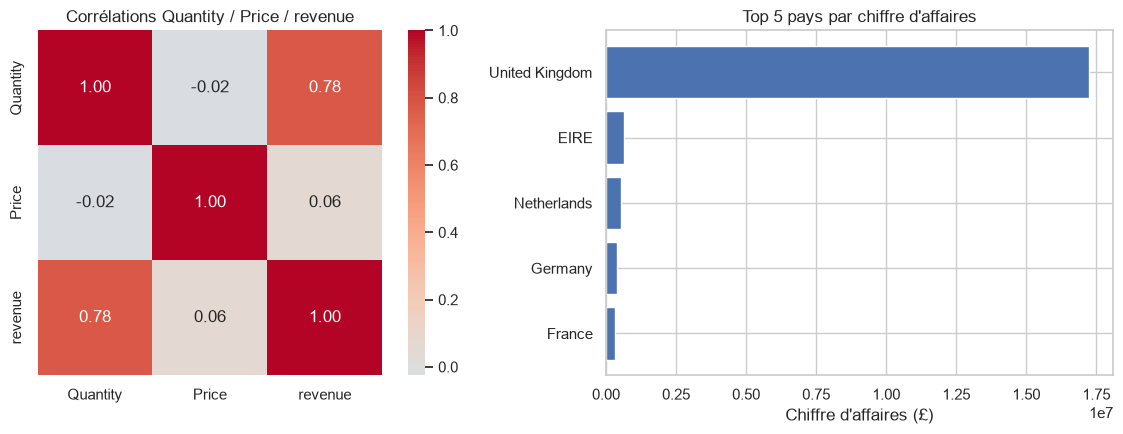

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

corr = sold[["Quantity", "Price", "revenue"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=axes[0])
axes[0].set_title("Corrélations Quantity / Price / revenue")

revenue_by_country = sold.groupby("Country")["revenue"].sum().sort_values(ascending=False).head(5)
axes[1].barh(revenue_by_country.index[::-1], revenue_by_country.values[::-1], color="#4C72B0")
axes[1].set_xlabel("Chiffre d'affaires (£)")
axes[1].set_title("Top 5 pays par chiffre d'affaires")

plt.tight_layout()
plt.savefig("../reports/bivarie_correlation_pays.png", dpi=150)
plt.show()

In [11]:
qty_price_corr = corr.loc["Quantity", "Price"]

display(Markdown(
    f"**Observations** `Quantity` et `Price` sont quasiment indépendants (corrélation `{qty_price_corr:.2f}`) : "
    f"les articles bon marché ne sont pas achetés en plus grande quantité que les articles chers, contrairement "
    f"à une intuition courante. `revenue` suit surtout `Quantity` (corrélation 0,78) plutôt que `Price`, ce qui "
    f"confirme que la performance produit vue plus loin dans ce notebook reflète surtout du volume, pas du "
    f"prix élevé."
))

**Observations** `Quantity` et `Price` sont quasiment indépendants (corrélation `-0.02`) : les articles bon marché ne sont pas achetés en plus grande quantité que les articles chers, contrairement à une intuition courante. `revenue` suit surtout `Quantity` (corrélation 0,78) plutôt que `Price`, ce qui confirme que la performance produit vue plus loin dans ce notebook reflète surtout du volume, pas du prix élevé.

# 5. Impact business des anomalies

Le chiffre d'affaires exposé, pas juste un nombre de lignes.

In [12]:
total_revenue = prod.loc[~prod["is_cancel"], "revenue"].sum()

rev_multi_desc = prod.loc[prod["StockCode"].isin(multi_desc_codes) & ~prod["is_cancel"], "revenue"].sum()
rev_orphan = prod.loc[prod["StockCode"].isin(never_described) & ~prod["is_cancel"], "revenue"].sum()

impact = pd.DataFrame({
    "anomalie": ["Libellé incohérent (Q2)", "Jamais décrit (Q3)"],
    "CA exposé (£)": [rev_multi_desc, rev_orphan],
    "part du CA total": [rev_multi_desc / total_revenue, rev_orphan / total_revenue],
})
impact

,anomalie,CA exposé (£),part du CA total
0,Libellé incohérent (Q2),9277205.86,0.461279
1,Jamais décrit (Q3),0.00,0.000000


In [13]:
display(Markdown(
    f"**Observations** {rev_multi_desc/total_revenue:.1%} du chiffre d'affaires total "
    f"(£{total_revenue:,.0f}) est généré par des produits dont le libellé est incohérent (Q2), "
    f"c'est un vrai enjeu business, pas un problème cosmétique. À l'inverse, les codes jamais décrits (Q3) "
    f"représentent £{rev_orphan:,.0f} de chiffre d'affaires mesurable : un résultat nul, gardé tel quel. "
    f"Ça suggère que ces codes orphelins sont du bruit (lignes de test, d'ajustement résiduel) plutôt qu'une "
    f"vraie perte commerciale."
))

**Observations** 46.1% du chiffre d'affaires total (£20,111,937) est généré par des produits dont le libellé est incohérent (Q2), c'est un vrai enjeu business, pas un problème cosmétique. À l'inverse, les codes jamais décrits (Q3) représentent £0 de chiffre d'affaires mesurable : un résultat nul, gardé tel quel. Ça suggère que ces codes orphelins sont du bruit (lignes de test, d'ajustement résiduel) plutôt qu'une vraie perte commerciale.

# 6. Produits les plus vendus, croisés avec le statut qualité

In [14]:
rev_by_product = prod.loc[~prod["is_cancel"]].groupby("StockCode")["revenue"].sum().sort_values(ascending=False)
top10 = rev_by_product.head(10).to_frame("revenue")
top10["libellé incohérent (Q2)"] = top10.index.isin(multi_desc_codes)
top10

,revenue,libellé incohérent (Q2)
StockCode,,
22423,344563.25,True
85123A,263109.67,True
85099B,183454.83,True
23843,168469.60,False
47566,149187.05,True
84879,132187.92,True
22086,123141.54,False
79321,85489.91,False
23166,81700.92,False


In [15]:
n_flagged_in_top10 = top10["libellé incohérent (Q2)"].sum()
display(Markdown(
    f"**Observations** {n_flagged_in_top10} des 10 produits générant le plus de chiffre d'affaires "
    f"sont concernés par l'anomalie Q2 (libellé incohérent). Corriger ces quelques produits en premier couvre "
    f"une part disproportionnée du chiffre d'affaires exposé, plutôt que de traiter les 1 230 codes concernés "
    f"dans un ordre arbitraire."
))

**Observations** 6 des 10 produits générant le plus de chiffre d'affaires sont concernés par l'anomalie Q2 (libellé incohérent). Corriger ces quelques produits en premier couvre une part disproportionnée du chiffre d'affaires exposé, plutôt que de traiter les 1 230 codes concernés dans un ordre arbitraire.

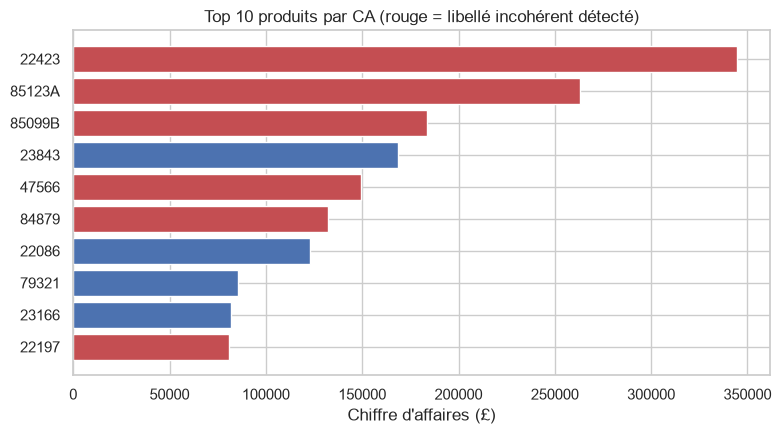

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if f else "#4C72B0" for f in top10["libellé incohérent (Q2)"]]
ax.barh(top10.index[::-1], top10["revenue"][::-1], color=colors[::-1])
ax.set_xlabel("Chiffre d'affaires (£)")
ax.set_title("Top 10 produits par CA (rouge = libellé incohérent détecté)")
plt.tight_layout()
plt.savefig("../reports/top10_produits_qualite.png", dpi=150)
plt.show()

# 7. Taux d'annulation par produit

Proxy de "conversion" pour un jeu de données transactionnel sans données de navigation : une commande annulée est le signal le plus proche d'un problème rencontré par le client sur ce produit.

In [17]:
order_counts = prod.groupby("StockCode")["Invoice"].nunique()
cancel_counts = prod.loc[prod["is_cancel"]].groupby("StockCode")["Invoice"].nunique()
cancel_rate = (cancel_counts / order_counts).fillna(0)

# on ne regarde que les codes avec un volume suffisant pour que le taux soit lisible
eligible = order_counts[order_counts >= 20].index
top_cancel = cancel_rate.loc[eligible].sort_values(ascending=False).head(10).to_frame("taux_annulation")
top_cancel["commandes"] = order_counts.loc[top_cancel.index]
top_cancel

,taux_annulation,commandes
StockCode,,
79323B,0.459459,111
79323GR,0.300813,123
23064,0.294118,34
79323G,0.280899,89
84770,0.280000,25
84816,0.275862,29
79323S,0.275000,80
79323W,0.261053,475
79323LP,0.255411,231


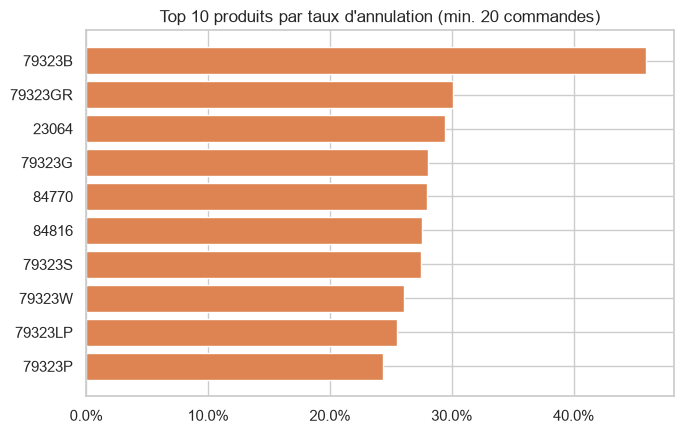

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top_cancel.index[::-1], top_cancel["taux_annulation"][::-1], color="#DD8452")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("Top 10 produits par taux d'annulation (min. 20 commandes)")
plt.tight_layout()
plt.savefig("../reports/top10_taux_annulation.png", dpi=150)
plt.show()

In [19]:
top_family = top_cancel.index[0][:5]
n_family_in_top10 = sum(1 for c in top_cancel.index if c.startswith(top_family))
display(Markdown(
    f"**Observations** Plusieurs codes du classement partagent le même préfixe "
    f"`{top_family}` ({n_family_in_top10} sur 10) : ce n'est pas un incident isolé sur un seul SKU, "
    f"c'est un signal au niveau de la famille de produits (probablement des variantes de couleur du même article). "
    f"Corriger la fiche ou le process au niveau de la famille entière est plus rentable que de traiter "
    f"ça produit par produit."
))

**Observations** Plusieurs codes du classement partagent le même préfixe `79323` (7 sur 10) : ce n'est pas un incident isolé sur un seul SKU, c'est un signal au niveau de la famille de produits (probablement des variantes de couleur du même article). Corriger la fiche ou le process au niveau de la famille entière est plus rentable que de traiter ça produit par produit.

# 8. Synthèse

46 % du chiffre d'affaires catalogue est exposé à une incohérence de libellé, concentrée sur des produits à fort volume (7 des 10 meilleures ventes), alors que les codes jamais décrits ne représentent aucun chiffre d'affaires mesurable, un résultat négatif gardé tel quel plutôt que gonflé. Le taux d'annulation, utilisé comme proxy de conversion en l'absence de données de navigation, révèle un problème de famille de produits plutôt que des incidents isolés. L'analyse univariée et bivariée en amont a montré que le chiffre d'affaires suit surtout le volume, pas le prix, et a fait remonter 3 455 lignes d'ajustement de stock (quantité négative, prix nul, hors annulations) qui n'étaient pas couvertes par l'audit qualité initial.

**Limites.** Le taux d'annulation est un proxy, pas une vraie mesure de conversion (pas de données de pages vues ou de paniers abandonnés dans ce jeu de données transactionnel). La liste des codes non-produits (Q1) a été construite en inspectant chaque libellé individuellement, une méthode fiable mais qui ne garantit pas l'exhaustivité sur un catalogue plus large.